# Classical Machine Learning Models

This notebook trains classical ML models (Random Forest, XGBoost, etc.) for domain and malware classification.

In [2]:
pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   - -------------------------------------- 2.1/72.0 MB 13.0 MB/s eta 0:00:06
   -- ------------------------------------- 5.0/72.0 MB 14.4 MB/s eta 0:00:05
   ---- ----------------------------------- 8.4/72.0 MB 14.9 MB/s eta 0:00:05
   ------ --------------------------------- 11.5/72.0 MB 14.7 MB/s eta 0:00:05
   ------- -------------------------------- 14.2/72.0 MB 14.1 MB/s eta 0:00:05
   --------- ------------------------------ 17.0/72.0 MB 14.1 MB/s eta 0:00:04
   ----------- ---------------------------- 19.9/72.0 MB 14.0 MB/s eta 0:00:04
   ------------ --------------------------- 22.5/72.0 MB 14.1 MB/s eta 0:00:04
   -------------- ------------------------- 25.7/72.0 MB 14.0 MB/s eta 0:00:04
   --------------- ------------------------ 28.6/72.0 MB 13.9 MB/s eta 0:00:04
   ----------------- ---------------------- 32.0/72.0 MB 14.1 MB/s eta 0:00:03
   ------------------- -------------------- 34.6/72.0 MB 14.0 MB


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb

# Set project root
project_root = Path().resolve().parent
models_dir = project_root / 'models'
models_dir.mkdir(exist_ok=True)

## 1. Domain Classification Model

In [4]:
# Load domain features
domain_features_path = project_root / 'data' / 'domains' / 'processed' / 'domain_features.csv'

# Initialize variables
df_domain = None
X_train = None
X_test = None
y_train = None
y_test = None

if domain_features_path.exists():
    df_domain = pd.read_csv(domain_features_path)
    print(f"✅ Loaded {len(df_domain)} domain samples")
    print(f"Features: {df_domain.columns.tolist()}")
    
    # Prepare data
    X = df_domain.drop('label', axis=1)
    y = df_domain['label']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"\nTrain set: {len(X_train)} samples")
    print(f"Test set: {len(X_test)} samples")
else:
    print(f"⚠️ Domain features not found: {domain_features_path}")
    print("Please run 01_feature_engineering.ipynb first")

✅ Loaded 199944 domain samples
Features: ['length', 'entropy', 'vowel_ratio', 'digit_ratio', 'consonant_ratio', 'label']

Train set: 159955 samples
Test set: 39989 samples


In [8]:
# Train Random Forest model for domains
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

if domain_features_path.exists() and len(df_domain) > 0:

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    y_pred_rf = rf.predict(X_test)
    print("📊 DGA Detection (Random Forest):")
    print(classification_report(y_test, y_pred_rf))

    
   # Evaluate
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Domain RF Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Save model
model_path = models_dir / 'domain_rf_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(rf, f)
print(f"\n✅ Saved model to: {model_path}")


📊 DGA Detection (Random Forest):
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     19989
           1       0.92      0.89      0.91     20000

    accuracy                           0.91     39989
   macro avg       0.91      0.91      0.91     39989
weighted avg       0.91      0.91      0.91     39989


✅ Domain RF Model Accuracy: 0.9086

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     19989
           1       0.92      0.89      0.91     20000

    accuracy                           0.91     39989
   macro avg       0.91      0.91      0.91     39989
weighted avg       0.91      0.91      0.91     39989


✅ Saved model to: D:\final_year_project\Qunatum-Enhanced_Threat_Intelligence\models\domain_rf_model.pkl


## 2. Malware Classification Model

In [26]:
import pandas as pd
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define paths
project_root = Path().resolve().parent
malware_features_path = project_root / 'data' / 'malware' / 'processed' / 'ember_features.csv'
models_dir = project_root / 'models'
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / 'ember_rf_model.pkl'

# Load data
if malware_features_path.exists():
    df_malware = pd.read_csv(malware_features_path)
    print(f"✅ Loaded {len(df_malware)} malware samples")
    print(f"Features: {df_malware.columns.tolist()}")

    # Preprocess
    X = df_malware.drop('label', axis=1).fillna(0)
    y = df_malware['label']

    for col in X.select_dtypes(include='object').columns:
        X = pd.get_dummies(X, columns=[col], prefix=col)

        y = df_malware['label'] 

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Train model
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Predict
    y_pred = rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    # Evaluation
    print("\n📊 Malware Detection (Random Forest):")
    print(classification_report(y_test, y_pred))
    print(f"✅ EMBER RF Model Accuracy: {accuracy:.4f}")

    # Save model
    with open(model_path, 'wb') as f:
        pickle.dump(rf_model, f)
    print(f"✅ Saved EMBER RF model to: {model_path}")
else:
    print(f"⚠️ Malware features file not found: {malware_features_path}")


✅ Loaded 116051 malware samples
Features: ['file_size', 'has_signature', 'machine', 'characteristics_count', 'histogram_sum', 'entropy_mean', 'label']

📊 Malware Detection (Random Forest):
              precision    recall  f1-score   support

           0       0.79      0.80      0.80     10468
           1       0.84      0.82      0.83     12743

    accuracy                           0.82     23211
   macro avg       0.81      0.81      0.81     23211
weighted avg       0.82      0.82      0.82     23211

✅ EMBER RF Model Accuracy: 0.8154
✅ Saved EMBER RF model to: D:\final_year_project\Qunatum-Enhanced_Threat_Intelligence\models\ember_rf_model.pkl


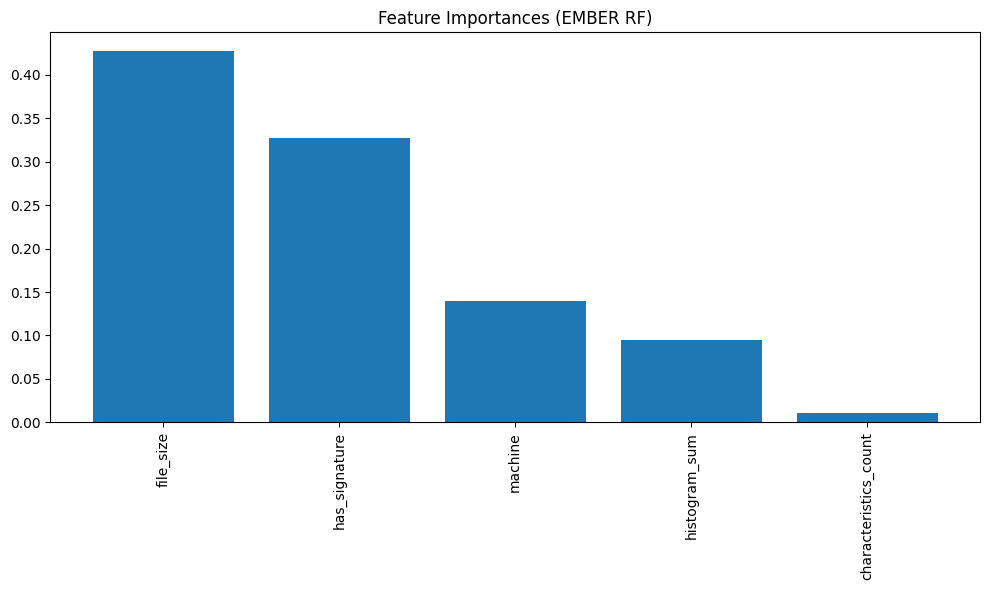

In [28]:
import matplotlib.pyplot as plt

importances = rf_ember.feature_importances_
features = X.columns if hasattr(X, 'columns') else df_ember.drop(columns=["label", "machine"]).columns
indices = importances.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (EMBER RF)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()


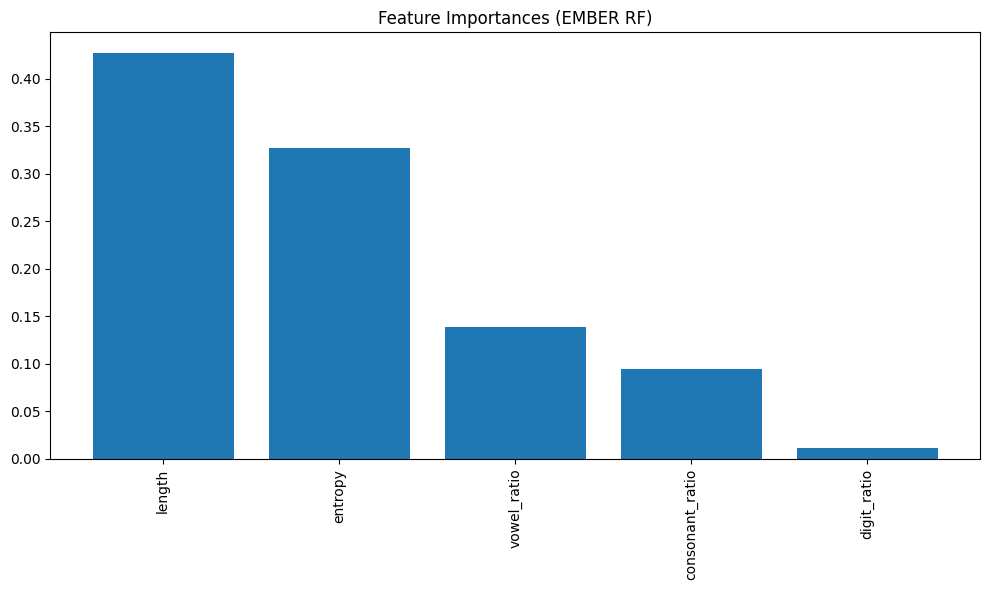

In [17]:
import matplotlib.pyplot as plt

importances = rf_ember.feature_importances_
features = X.columns if hasattr(X, 'columns') else df_ember.drop(columns=["label", "machine"]).columns
indices = importances.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (EMBER RF)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()
